# Day 2 (R parallel): diversification opportunities with the `economiccomplexity` package

This is the R companion to the Day 2 Python notebook. The Python version hand-rolls proximity, the product space, and density one matrix product at a time. Here we hand the same steps to the standard R package, `economiccomplexity`, and check that its proximity, density, and diversification shortlist reproduce the ones you build by hand in Python. The point is the one from Day 1: the numbers you assemble by hand are the numbers a maintained package computes, so the method is trustworthy rather than a black box.

We reuse the same skeleton the Python notebook uses, pair products by proximity, place your country on the product space, score each product by density, then rank the opportunities, and we keep the same `COUNTRY`, `COMPARATORS`, and `YEAR` knobs. Edit them at the top to point the notebook at your own country.

## 0. Setup: load the data packet

Same packet as Day 1, plus the two product-space layout files. If anything is missing we stop right away and name the exact file you need.

In [1]:
suppressMessages({
  library(arrow) # read the packet's .parquet files
  library(dplyr) # filter, select, group, summarise
  library(tidyr) # reshape long and wide
  library(readr) # read the reference tables
  library(ggplot2) # the product-space figure
  library(economiccomplexity) # balassa_index(), proximity(), density(), complexity_outlook()
})

# --- The ONE place you edit to make this notebook about your own country. ------
# Codes are ISO 3166-1 alpha-2 (two letters). MA = Morocco, EG = Egypt,
# TN = Tunisia, KR = Republic of Korea. See reference/units.csv.
COUNTRY <- "MA" # the focus country (Morocco)
COMPARATORS <- c("EG", "TN", "KR") # Egypt, Tunisia (MENA) + Korea (frontier)
YEAR <- 2023 # latest year in the packet
# -------------------------------------------------------------------------------

# Resolve the packet path relative to this notebook so it runs from a clean
# checkout regardless of where the repo lives on disk.
PACKET <- normalizePath(
  file.path("..", "..", "data", "processed", "morocco_data_packet"),
  mustWork = FALSE
)

# Fail LOUD on anything missing, naming the exact file. Today that includes the
# two product-space layout files that ship inside reference/.
required <- c(
  file.path(PACKET, "exports", "outputs.parquet"),
  file.path(PACKET, "exports", "densities.parquet"),
  file.path(PACKET, "reference", "fields.csv"),
  file.path(PACKET, "reference", "units.csv"),
  file.path(PACKET, "reference", "umap_layout_hs92.csv"),
  file.path(PACKET, "reference", "top_edges_hs92.csv")
)
missing <- required[!file.exists(required)]
if (length(missing) > 0) {
  stop(
    "Required packet file(s) not found:\n  ", paste(missing, collapse = "\n  "), "\n",
    "Download 'morocco_data_packet' from the shared course link and unzip it ",
    "into data/processed/ so these paths resolve. If you downloaded the packet ",
    "before Day 2, re-fetch it so the product-space layout files are included."
  )
}
cat("Packet found:", PACKET, "\n")
cat("Focus country:", COUNTRY, "| comparators:", paste(COMPARATORS, collapse = ", "), "| year:", YEAR, "\n")

Packet found: /Users/shg309/Library/CloudStorage/Dropbox-Personal/Education/hks_cid_growth_lab/misc/morocco_summer_school/data/processed/morocco_data_packet 


Focus country: MA | comparators: EG, TN, KR | year: 2023 


In [2]:
# Load today's tables. outputs.parquet and fields.csv are Day 1's tables; the two
# layout files position the product space exactly as the Atlas draws it. We read
# the small reference tables with check.names = FALSE so the "Field ID" column
# keeps its space and the codes line up with the packet.
exports <- read_parquet(file.path(PACKET, "exports", "outputs.parquet"))
fields <- read.csv(
  file.path(PACKET, "reference", "fields.csv"),
  check.names = FALSE, stringsAsFactors = FALSE
)
prod_name <- setNames(fields$`Field Name`, fields$`Field ID`)

# One year of trade in long form: country (Unit), product (Field ID), value (Outputs).
year_long <- exports %>%
  filter(Period == YEAR) %>%
  select(Unit, `Field ID`, Outputs)
cat("countries:", n_distinct(year_long$Unit), "| products:", n_distinct(year_long$`Field ID`), "\n")

countries: 191 | products: 862 


## 1. Rebuild Day 1's Mcp and diversity

Everything today grows out of the binary Mcp matrix you built on Day 1. `balassa_index(discrete = TRUE, cutoff = 1)` does the whole Normalize, Benchmark, Binarize sequence in one call, and diversity is the row sum.

In [3]:
mcp <- balassa_index(
  year_long,
  discrete = TRUE, cutoff = 1,
  country = "Unit", product = "Field ID", value = "Outputs"
)
diversity <- rowSums(mcp) # products each country makes competitively
ubiquity <- colSums(mcp) # countries that make each product

cat(COUNTRY, "diversity:", diversity[COUNTRY], "\n")
cat("matrix:", nrow(mcp), "countries x", ncol(mcp), "products\n")

# Self-check: the Day 1 handshake. Morocco's 2023 diversity was 129 yesterday and
# must be 129 today. The package's RCA >= 1 rule reproduces the by-hand RCA > 1
# count exactly, since no product sits at RCA exactly 1.
if (diversity[COUNTRY] != 129) {
  stop(
    "Morocco's diversity is ", diversity[COUNTRY], " but Day 1 printed 129. ",
    "If it moved, the RCA or binarization step drifted."
  )
}
cat("OK: yesterday's Mcp reproduced (Morocco diversity = 129).\n")

MA diversity: 129 


matrix: 191 countries x 862 products


OK: yesterday's Mcp reproduced (Morocco diversity = 129).


## 2. Closing the threshold question: complexity without the cutoff

On Day 1 the RCA cutoff of 1 felt arbitrary. This morning's lecture gave the answer: do not threshold at all. Transform RCA into a bounded weight, m_hat = RCA / (1 + RCA), which sends an RCA of 1 to 0.5 and never throws anything away, then run the same eigenvalue routine on the continuous matrix. The package accepts any non-negative weight matrix, so we pass m_hat straight in and compare the ranking to the binary one.

In [4]:
# Continuous RCA from the same call with discrete = FALSE, then the Hausmann
# transformation cell by cell. balassa_index returns a matrix, so this is one
# elementwise line with no loop.
rca <- balassa_index(
  year_long,
  discrete = FALSE,
  country = "Unit", product = "Field ID", value = "Outputs"
)
rca <- as.matrix(rca) # dense so the arithmetic below reads plainly
m_hat <- rca / (1 + rca)
cat("m_hat range:", round(min(m_hat), 3), "to", round(max(m_hat), 4), "(RCA = 1 maps to 0.5)\n")

m_hat range: 0 to 0.9998 (RCA = 1 maps to 0.5)


In [5]:
# complexity_measures with method = "eigenvalues" takes the SECOND eigenvector of
# the reflection operator, the same object Day 1's Python notebook built by hand
# (Day 2 packages it as a provided function). It standardizes the result and
# prints a note when it flips the sign so the index rises with diversity. We run
# it twice: once on the binary Mcp (yesterday's index) and once on continuous m_hat.
cm_bin <- complexity_measures(mcp, method = "eigenvalues")
eci_bin <- cm_bin$complexity_index_country
pci_bin <- cm_bin$complexity_index_product

cm_con <- complexity_measures(m_hat, method = "eigenvalues")
eci_con <- cm_con$complexity_index_country

common_c <- intersect(names(eci_bin), names(eci_con))
rho_bc <- cor(eci_bin[common_c], eci_con[common_c], method = "spearman")
cat(
  COUNTRY, "binary ECI:", round(eci_bin[COUNTRY], 3),
  "(rank", rank(-eci_bin)[COUNTRY], ") | continuous ECI:", round(eci_con[COUNTRY], 3),
  "(rank", rank(-eci_con)[COUNTRY], ")\n"
)
cat("Comparator ECI shift (binary rank -> continuous rank):\n")
for (code in COMPARATORS) {
  if (code %in% common_c) {
    cat("  ", code, ":", rank(-eci_bin)[code], "->", rank(-eci_con)[code], "\n")
  }
}
cat("Spearman(binary ECI, continuous ECI) =", round(rho_bc, 3), "over", length(common_c), "countries\n")

# Self-check: the two rankings agree strongly but NOT perfectly. Perfect agreement
# would mean the threshold never mattered; a weak value would mean the index is
# fragile. The lecture's claim, and the Python notebook's 0.965, live in between.
if (!(rho_bc > 0.9 && rho_bc < 0.999)) {
  stop(
    "binary and continuous ECI should rank countries almost, but not exactly, ",
    "alike (got Spearman ", round(rho_bc, 3), "). Far lower means an eigenvector ",
    "or sign error; near 1.0 would mean the threshold changed nothing."
  )
}
cat("OK: dropping the threshold barely moves the ranking (Spearman", round(rho_bc, 3), ").\n")

applying sign correction to product index...



applying sign correction to country index...



MA binary ECI: -0.468 (rank 123 ) | continuous ECI: -0.062 (rank 111 )


Comparator ECI shift (binary rank -> continuous rank):


   EG : 97 -> 97 
   TN : 72 -> 62 
   KR : 3 -> 2 


Spearman(binary ECI, continuous ECI) = 0.965 over 191 countries


OK: dropping the threshold barely moves the ranking (Spearman 0.965 ).


From here on we use the binary Mcp, as the product-space tradition and the packages do. You now know the robustness check to run when a threshold decision worries you.

## 3. Proximity from the package

The morning defined the proximity between two products as the minimum of the two conditional probabilities of co-export. `proximity()` computes that for all 862 products in one call. It returns a product-by-product matrix with a 1 on the diagonal, since a product is perfectly co-exported with itself. The Day 2 Python notebook zeroed the diagonal by convention so the density denominator below does not count a product against itself, so we zero it here too before we compare.

In [6]:
prox <- proximity(mcp, compute = "product")
phi <- as.matrix(prox$proximity_product) # dense copy for the hand comparisons
diag(phi) <- 0 # match the Python convention: a product is not related to itself

cat("phi:", nrow(phi), "x", ncol(phi), "| symmetric:", isTRUE(all.equal(phi, t(phi))), "\n")
cat(
  "phi(Women's Knit Shirts P - 6106, Women's Knit Suits P - 6104) =",
  round(phi["P - 6106", "P - 6104"], 3), "\n"
)

# Self-check: the lecture's flagship pair. Women's shirts and women's suits sit
# near the very top of all pairs. The Python hand-roll gets 0.702 on 2023 data
# (the lecture's Table 2 showed 0.967 on 2010 data; method stable, number not
# identical). We match the Python value to two decimals after zeroing the diagonal.
if (abs(phi["P - 6106", "P - 6104"] - 0.702) > 0.01) {
  stop(
    "phi(P - 6106, P - 6104) should reproduce the Python hand-roll's 0.702. ",
    "Got ", round(phi["P - 6106", "P - 6104"], 3),
    ". Check that the diagonal was zeroed and the pair is off-diagonal."
  )
}
cat("OK: the shirts/suits pair matches the Python proximity (0.702).\n")

phi: 862 x 862 | symmetric: TRUE 


phi(Women's Knit Shirts P - 6106, Women's Knit Suits P - 6104) = 0.702 


OK: the shirts/suits pair matches the Python proximity (0.702).


In [7]:
# Cross-check on Day 1's toy table, small enough to count by hand. Only Country B
# exports both Wheat and Textiles, so phi(Wheat, Textiles) = 1 / max(1, 2) = 0.5;
# only Country A exports both Motorcycles and Cell phones, so that pair = 1.0.
# We drop the zero-value rows because balassa_index reads a long table with one
# row per country-product actually exported.
toy <- data.frame(
  country = rep(c("Country A", "Country B", "Country C"), each = 4),
  product = rep(c("Wheat", "Textiles", "Motorcycles", "Cell phones"), times = 3),
  value = c(10, 40, 100, 300, 150, 100, 10, 0, 20, 200, 1, 0),
  stringsAsFactors = FALSE
)
toy <- toy[toy$value > 0, ]
toy_mcp <- balassa_index(toy, discrete = TRUE, cutoff = 1)
toy_phi <- as.matrix(proximity(toy_mcp, compute = "product")$proximity_product)
diag(toy_phi) <- 0
cat("toy phi(Wheat, Textiles) =", toy_phi["Wheat", "Textiles"], "\n")
cat("toy phi(Motorcycles, Cell phones) =", toy_phi["Motorcycles", "Cell phones"], "\n")

# Self-check: exact by construction on the toy.
if (abs(toy_phi["Wheat", "Textiles"] - 0.5) > 1e-9 ||
  abs(toy_phi["Motorcycles", "Cell phones"] - 1.0) > 1e-9) {
  stop(
    "on the toy table the package must give phi(Wheat, Textiles) = 0.5 and ",
    "phi(Motorcycles, Cell phones) = 1.0, the same min-of-conditionals the ",
    "Python notebook counts by hand."
  )
}
cat("OK: the package reproduces the hand-counted toy proximities.\n")

toy phi(Wheat, Textiles) = 0.5 


toy phi(Motorcycles, Cell phones) = 1 


OK: the package reproduces the hand-counted toy proximities.


## 4. The product space: place your country on the map

We draw the Growth Lab's published product-space layout, the same one the Python notebook draws. The node positions come from UMAP and the edge list keeps each product's strongest links. We highlight the products your country exports competitively so its position on the map is legible. This is a static ggplot rather than the Python notebook's interactive figure, so it reads the same at a glance without the hover labels.

In [8]:
# The layout ships with HS92 codes that need zero-padding to 4 digits to match our
# Field IDs (0714, not 714). We read the code columns as character so a leading
# zero is not lost, then pad and prefix.
pad4 <- function(x) formatC(as.integer(x), width = 4, flag = "0")
layout_nodes <- read.csv(
  file.path(PACKET, "reference", "umap_layout_hs92.csv"),
  colClasses = c(product_hs92_code = "character"), check.names = FALSE
)
layout_nodes$code <- pad4(layout_nodes$product_hs92_code)
layout_nodes$field <- paste0("P - ", layout_nodes$code)

# World exports per product (the column total of the trade matrix) sizes each node,
# and Morocco's Mcp row flags the products it makes competitively.
world_exports <- year_long %>%
  group_by(`Field ID`) %>%
  summarise(world_exports = sum(Outputs), .groups = "drop")
we_lookup <- setNames(world_exports$world_exports, world_exports$`Field ID`)
ma_row <- mcp[COUNTRY, ]

nodes <- layout_nodes %>%
  mutate(
    name = prod_name[field],
    world_exports = we_lookup[field],
    in_basket = !is.na(ma_row[field]) & ma_row[field] == 1
  ) %>%
  filter(!is.na(world_exports))
nodes$node_size <- sqrt(nodes$world_exports / max(nodes$world_exports)) # Atlas scaling

# Edges ship mirrored (each pair appears both ways). Sort each pair and drop the
# duplicate so every link is drawn once, then attach the endpoint coordinates.
layout_edges <- read.csv(
  file.path(PACKET, "reference", "top_edges_hs92.csv"),
  colClasses = "character", check.names = FALSE
)
layout_edges$source <- pad4(layout_edges$product_hs92_code_source)
layout_edges$target <- pad4(layout_edges$product_hs92_code_target)
pair_key <- apply(cbind(layout_edges$source, layout_edges$target), 1, function(r) {
  paste(sort(r), collapse = "_")
})
layout_edges <- layout_edges[!duplicated(pair_key), ]
xy <- layout_nodes[, c("code", "product_space_x", "product_space_y")]
edges <- layout_edges %>%
  left_join(xy, by = c("source" = "code")) %>%
  rename(x = product_space_x, y = product_space_y) %>%
  left_join(xy, by = c("target" = "code")) %>%
  rename(xend = product_space_x, yend = product_space_y) %>%
  filter(!is.na(x) & !is.na(xend))

cat(
  "layout nodes:", nrow(nodes), "| highlighted (", COUNTRY, "basket):", sum(nodes$in_basket),
  "| edges:", nrow(edges), "\n"
)

layout nodes: 862 | highlighted ( MA basket): 129 | edges: 2158 


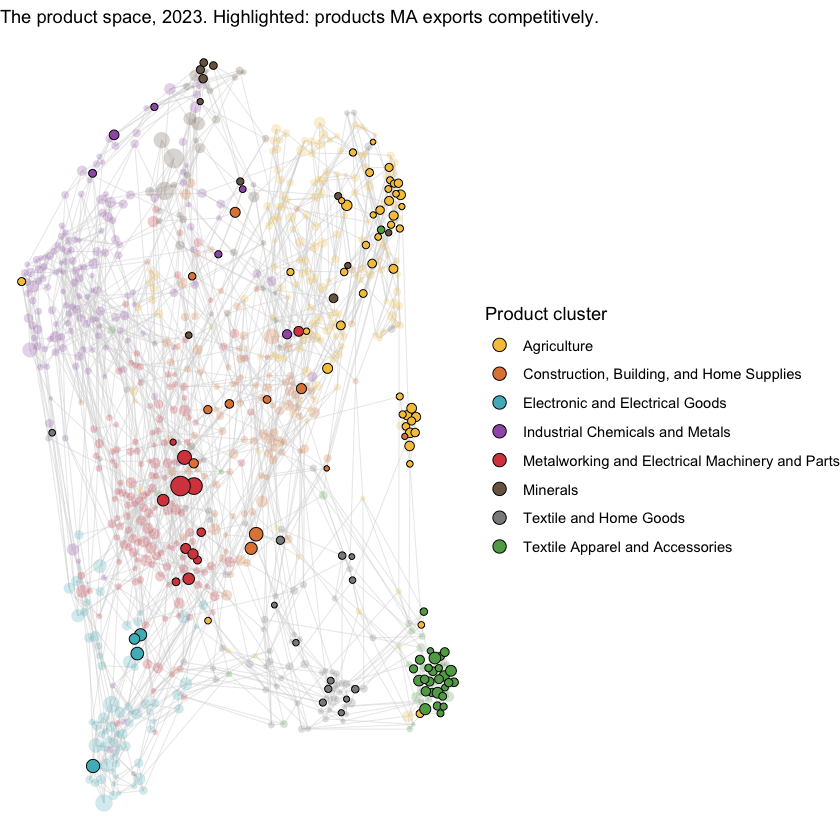

In [9]:
# Cluster colors follow the Atlas legend the morning slide used (the same hex map
# as the Python notebook). R does not know matplotlib color names, so every color
# is a hex string.
CLUSTER_COLORS <- c(
  "Agriculture" = "#F5C548",
  "Minerals" = "#7A6552",
  "Industrial Chemicals and Metals" = "#A05FB5",
  "Metalworking and Electrical Machinery and Parts" = "#D7484B",
  "Electronic and Electrical Goods" = "#4FB8C4",
  "Construction, Building, and Home Supplies" = "#E08544",
  "Textile and Home Goods" = "#8B8B8B",
  "Textile Apparel and Accessories" = "#5FA755"
)

# Two point layers on the same fill scale so there is one legend: the products the
# country does not make sit faint (alpha 0.25, thin grey outline), the ones it does
# make sit at full color with a black outline (shape 21). Node area scales with the
# square root of world trade, as on the Atlas.
ggplot() +
  geom_segment(
    data = edges, aes(x = x, y = y, xend = xend, yend = yend),
    color = "grey85", linewidth = 0.15
  ) +
  geom_point(
    data = subset(nodes, !in_basket),
    aes(product_space_x, product_space_y, fill = product_space_cluster_name, size = node_size),
    shape = 21, color = "grey70", stroke = 0.1, alpha = 0.25
  ) +
  geom_point(
    data = subset(nodes, in_basket),
    aes(product_space_x, product_space_y, fill = product_space_cluster_name, size = node_size),
    shape = 21, color = "black", stroke = 0.4, alpha = 1
  ) +
  scale_fill_manual(values = CLUSTER_COLORS, name = "Product cluster") +
  scale_size_continuous(range = c(0.6, 5.5), guide = "none") +
  guides(fill = guide_legend(override.aes = list(size = 3.5, alpha = 1))) +
  labs(
    title = paste0(
      "The product space, ", YEAR, ". Highlighted: products ", COUNTRY,
      " exports competitively."
    )
  ) +
  theme_void(base_size = 11) +
  theme(
    plot.background = element_rect(fill = "white", color = NA),
    panel.background = element_rect(fill = "white", color = NA),
    plot.title = element_text(size = 11, hjust = 0)
  )

In [10]:
# Self-check: the join actually worked and the highlight really is the basket.
matched <- mean(nodes$field %in% colnames(mcp))
if (!(matched > 0.95)) {
  stop(
    "only ", round(100 * matched), "% of layout products matched the trade matrix. ",
    "The HS92 codes must be zero-padded to 4 digits before prefixing with 'P - '."
  )
}
expected_hl <- sum(mcp[COUNTRY, intersect(colnames(mcp), nodes$field)] == 1)
if (sum(nodes$in_basket) != expected_hl) {
  stop(
    "the number of highlighted nodes must equal the country's diversity ",
    "restricted to products present in the layout. Check the in_basket mapping."
  )
}
cat(
  "OK: layout joined (", sprintf("%.0f%%", 100 * matched), "matched) and",
  sum(nodes$in_basket), "products highlighted for", COUNTRY, ".\n"
)

OK: layout joined ( 100% matched) and 129 products highlighted for MA .


## 5. Density: how close is each product to what you already do?

Density is the share of a product's total relatedness that your country already holds. Sum the proximities from a product to everything the country exports, divide by the product's total proximity. We hand-roll it here in one matrix product, exactly as the Python notebook does, then confirm the package's own `density()` agrees.

In [11]:
# Numerator: for each country row, add the proximities from each product to
# everything the country already exports. Denominator: each product's total
# proximity, the column sum of the zeroed-diagonal phi. The ratio is the SHARE.
mcp_mat <- as.matrix(mcp)
stopifnot(identical(colnames(mcp_mat), colnames(phi))) # aligned product order
density <- sweep(mcp_mat %*% phi, 2, colSums(phi), "/")

ma_density <- density[COUNTRY, ]
ma_mcp <- mcp_mat[COUNTRY, ]
in_basket_mean <- mean(ma_density[ma_mcp == 1])
out_basket_mean <- mean(ma_density[ma_mcp == 0])
cat(COUNTRY, "density range:", round(min(density), 3), "to", round(max(density), 3), "\n")
cat(
  COUNTRY, "mean density inside its basket:", round(in_basket_mean, 3),
  "| outside:", round(out_basket_mean, 3), "\n"
)

# Self-check, three layers.
#   (1) A share lives in [0, 1].
#   (2) The invariant a shortcut cannot fake: relatedness concentrates around what
#       you already do, so the products the country exports sit at higher average
#       density than the ones it does not.
#   (3) Both means match the Python hand-roll (0.215 inside, 0.139 outside).
if (!(min(density) >= 0 && max(density) <= 1 + 1e-9)) {
  stop("density is a share and must lie in [0, 1]. Values above 1 mean the denominator is missing.")
}
if (!(in_basket_mean > out_basket_mean)) {
  stop("average density must be higher on products the country already exports. Check the matrix orientation.")
}
if (abs(in_basket_mean - 0.215) > 0.03 || abs(out_basket_mean - 0.139) > 0.03) {
  stop(
    "the in-basket and out-of-basket means should reproduce the Python values ",
    "(0.215 and 0.139). Got ", round(in_basket_mean, 3), " and ",
    round(out_basket_mean, 3), "."
  )
}
cat("OK: density is a bounded share and the basket sits denser than the rest, matching Python.\n")

MA density range: 0 to 0.867 


MA mean density inside its basket: 0.215 | outside: 0.139 


OK: density is a bounded share and the basket sits denser than the rest, matching Python.


In [12]:
# The package computes the same density in one call. We pass the package's own
# proximity object (its density routine handles the diagonal internally), then
# rank-correlate against the hand-roll for Morocco. Same definition, same data.
pkg_density <- as.matrix(economiccomplexity::density(mcp, prox$proximity_product))
common_pd <- intersect(names(ma_density), colnames(pkg_density))
rho_pkg <- cor(ma_density[common_pd], pkg_density[COUNTRY, common_pd], method = "spearman")
cat("Spearman(hand-rolled density, package density) for", COUNTRY, "=", round(rho_pkg, 4), "\n")
if (!(rho_pkg > 0.99)) {
  stop("the hand-rolled and package densities should rank products nearly identically (Spearman > 0.99).")
}
cat("OK: the package reproduces the hand-rolled density.\n")

Spearman(hand-rolled density, package density) for MA = 0.9993 


OK: the package reproduces the hand-rolled density.


In [13]:
# Validation against WIPO's published density, as on Day 1. Every row of
# densities.parquet is the Production dimension (Field IDs start with P), so a
# Period and Unit filter is all we need.
wipo_density <- read_parquet(file.path(PACKET, "exports", "densities.parquet")) %>%
  filter(Period == YEAR, Unit == COUNTRY)
wipo_v <- setNames(wipo_density$`Relatedness Density`, wipo_density$`Field ID`)
common_w <- intersect(names(ma_density), names(wipo_v))
rho_wipo <- cor(ma_density[common_w], wipo_v[common_w], method = "spearman")
cat("Spearman(our density, WIPO density) =", round(rho_wipo, 3), "over", length(common_w), "products\n")

# Self-check: positive, real, and imperfect by design. Density inherits every
# upstream choice twice over, since WIPO's presence rule differs (Day 1's lesson)
# AND its proximity matrix differs, and the two gaps compound. This is why the
# agreement is weaker than Day 1's PCI-vs-WIPO 0.923.
if (!(rho_wipo > 0.2 && rho_wipo < 0.95)) {
  stop(
    "our density should agree with WIPO's directionally but imperfectly ",
    "(got ", round(rho_wipo, 3), "). Near 0 suggests a broken pipeline; near 1 ",
    "would mean you loaded WIPO's column instead of computing your own."
  )
}
cat("OK: real but imperfect agreement with WIPO (", round(rho_wipo, 3), "), as expected.\n")

Spearman(our density, WIPO density) = 0.538 over 862 products


OK: real but imperfect agreement with WIPO ( 0.538 ), as expected.


## 6. The diversification shortlist

Cross density with PCI. Density says how reachable a product is from your basket; PCI says how sophisticated it is. The interesting corner is high density and high PCI, nearby and worth having. `complexity_outlook()` adds two summary measures from the same trade-off: a complexity outlook gain (COG) per product, how much new reach entering it would unlock, and one complexity outlook index (COI) per country.

In [14]:
# The package's outlook uses the proximity object with its diagonal intact and the
# product complexity index we already computed. COG is a country-by-product matrix;
# we pull Morocco's row for the table below.
outlook <- complexity_outlook(mcp, prox$proximity_product, pci_bin)
cog <- as.matrix(outlook$complexity_outlook_gain)

# Candidates are products the country does NOT yet export competitively (RCA < 1).
# We keep those above the median PCI of the candidate set, the same filter the
# Python notebook applies, then rank by density.
ma_rca <- rca[COUNTRY, ]
candidates <- data.frame(
  field = names(ma_density),
  density = as.numeric(ma_density),
  pci = as.numeric(pci_bin[names(ma_density)]),
  rca = as.numeric(ma_rca[names(ma_density)]),
  cog = as.numeric(cog[COUNTRY, names(ma_density)]),
  stringsAsFactors = FALSE
)
candidates <- candidates[candidates$rca < 1 & !is.na(candidates$pci), ]
pci_median <- median(candidates$pci)

opportunities <- candidates[candidates$pci > pci_median, ]
opportunities <- opportunities[order(-opportunities$density), ][1:15, ]
opportunities$product <- prod_name[opportunities$field]
opportunities$world_exports_bnUSD <- round(we_lookup[opportunities$field] / 1e9, 1)
print(
  opportunities[, c("product", "density", "pci", "cog", "world_exports_bnUSD")],
  row.names = FALSE, digits = 3
)

# The package also returns a country-level complexity outlook index. Its scale
# differs from the Python package's COI (the two packages standardize it
# differently), so we rank opportunities with the per-product COG above and do
# not compare the scalar index across the two implementations.

# Self-check: the table is what it claims to be.
if (!all(opportunities$rca < 1)) {
  stop("every opportunity must be a product the country does NOT yet export competitively (RCA < 1).")
}
if (!(nrow(opportunities) == 15 && !is.unsorted(rev(opportunities$density)))) {
  stop("the opportunity table must hold 15 rows sorted by density, largest first.")
}
if (any(is.na(opportunities$cog))) {
  stop("every opportunity row needs its COG from complexity_outlook(). Check the join on product IDs.")
}
# Name the top families from the table itself, so the message stays true when
# COUNTRY is changed (a hardcoded list would silently print the wrong story).
top_products <- paste(head(opportunities$product, 3), collapse = ", ")
cat(
  "OK:", nrow(opportunities), "ranked opportunities for", COUNTRY,
  "(top by density:", top_products, ").\n"
)

                       product density   pci    cog world_exports_bnUSD
              Steel Structures   0.170 0.469 0.0963                52.3
            Hair Care Products   0.168 0.355 0.0937                13.3
           Aluminum Structures   0.167 0.341 0.0950                14.9
        Personal Care Products   0.167 0.268 0.0725                11.6
                     New Tires   0.161 0.264 0.1337                75.0
          Other Plastic Sheets   0.160 0.677 0.2022                24.2
       Prefabricated Buildings   0.160 0.325 0.0878                 9.1
         Plastic Sanitary Ware   0.160 0.514 0.1797                 4.1
           Books and Brochures   0.160 0.282 0.1065                10.8
             Clothing Hardware   0.158 0.344 0.2062                 3.3
            Cast Iron Articles   0.158 0.568 0.1865                 6.4
           Other Zinc Articles   0.157 0.268 0.2066                 1.0
 Textile and Leather Finishing   0.157 0.491 0.2093             

OK: 15 ranked opportunities for MA (top by density: Steel Structures, Hair Care Products, Aluminum Structures ).


The model ranks; you judge. Proximity is revealed co-location, not a causal recipe, and all of it lives on trade data alone. Tomorrow's regressions test whether nearby products are actually entered more often, which is the empirical claim behind this table.

## 7. Reconcile with the Python hand-roll

Every headline number the Python notebook computes by hand comes back from the package. Because the package and the Python hand-roll compute the same objects on the same data, they agree to precision on the exact quantities and by rank on the derived ones.

| Metric | Python (hand-rolled) | R (`economiccomplexity`) |
|---|---|---|
| Morocco diversity | 129 | 129 |
| Morocco binary ECI (standardized) | -0.47 | -0.468 |
| Spearman(binary ECI, continuous ECI) | 0.965 | 0.965 |
| phi(Women's Knit Shirts, Women's Knit Suits) | 0.702 | 0.702 |
| Toy phi(Wheat, Textiles) | 0.5 | 0.5 |
| Toy phi(Motorcycles, Cell phones) | 1.0 | 1.0 |
| Morocco mean density inside basket | 0.215 | 0.215 |
| Morocco mean density outside basket | 0.139 | 0.139 |
| Spearman(our density, WIPO density) | 0.538 | 0.538 |
| Top opportunity families | Steel/Aluminum Structures, Hair/Personal Care, New Tires | same |

The one real gap is against WIPO, near 0.54 rather than 1.0, and that is a difference of method rather than a mistake. Density inherits WIPO's different presence rule and its different proximity matrix at once, so the two gaps compound and the agreement is looser than Day 1's PCI comparison. Use the package when you want the numbers fast and audited; keep the by-hand version in mind so you always know what the package is doing.